In [ ]:
# Install required packages
!pip install transformers
!pip install datasets
!pip install evaluate
!pip install accelerate
!pip install pillow
!pip install timm

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-none-win_amd64.whl.metadata (6.8 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-none-win_amd64.whl (2.2 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [ ]:
# ============================================
# FINAL FIX SCRIPT
# ============================================

import sys
import subprocess

print("🔧 FIXING PYTORCH CUDA INSTALLATION...")

# Uninstall all torch packages
!pip uninstall torch torchvision torchaudio -y

# Clear cache
!pip cache purge

# Install correct CUDA versions
!pip install torch==2.7.1+cu118 torchvision==0.22.1+cu118 torchaudio==2.7.1+cu118 --index-url https://download.pytorch.org/whl/cu118

print("\n🔧 FIXING DATASETS AND EVALUATE...")
!pip install --upgrade pyarrow
!pip install datasets==2.14.6 evaluate==0.4.1

print("\n✅ VERIFYING FIXES...")
print("-" * 50)

import torch
import torchvision
import datasets
import evaluate

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"Datasets: {datasets.__version__}")
print(f"Evaluate: {evaluate.__version__}")

print("\n✅ All fixes applied!")

In [ ]:
# Try with verbose output to see what's happening
!pip install torch==2.7.1+cu118 torchvision==0.22.1+cu118 torchaudio==2.7.1+cu118 --index-url https://download.pytorch.org/whl/cu118 --force-reinstall --verbose

^C


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.3.5 which is incompatible.
datasets 2.14.6 requires fsspec[http]<=2023.10.0,>=2023.1.0, but you have fsspec 2025.12.0 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.3.5 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.3.5 which is incompatible.
s3fs 2024.3.1 requires fsspec==2024.3.1, but you have fsspec 2025.12.0 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.3.5 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.3.5 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.0.0 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf

Using pip 24.0 from C:\Users\pacle\anaconda3\Lib\site-packages\pip (python 3.12)
Looking in indexes: https://download.pytorch.org/whl/cu118
  Obtaining dependency information for torch==2.7.1+cu118 from https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (27 kB)
  Obtaining dependency information for torchvision==0.22.1+cu118 from https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Obtaining dependency information for torchaudio==2.7.1+cu118 from https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (6.8 kB)


# -------------------------------------
# DEBUGGING HELL UPTOP RUN CODE BELOW**
# -------------------------------------

In [5]:
!pip install -q evaluate

### for it to run on colab, first download the dataset

In [7]:
!pip -q install kaggle
!pip -q install "fastprogress==1.0.3"

In [1]:
from pathlib import Path
import json

p = Path("Dr_Professor_Kens_solution.ipynb")

nb = json.loads(p.read_text())
nb.get("metadata", {}).pop("widgets", None)

p.write_text(json.dumps(nb, indent=1))

2431017

In [8]:
!export KAGGLE_API_TOKEN= ### here put ur kaggle api token"

In [9]:
%%bash
mkdir -p /root/.config/kaggle/
cat <<EOF > /root/.config/kaggle/kaggle.json
{
  "username": ### kaggle username,
  "key": ### kaggle username
}
EOF

chmod 600 /root/.config/kaggle/kaggle.json

In [10]:
!kaggle datasets list | head

ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          11392        229  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           9793        154  1.0              
shree0910/online-vs-in-store-shopping-behaviour-dataset             Online vs In-Store Shopping Behaviour Dataset          354896  2026-02-18 08:16:20.137000           1067         24  1.0

In [11]:
!kaggle datasets download -d benpepperpots/rust-iron-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/benpepperpots/rust-iron-dataset
License(s): unknown
 99% 719M/729M [00:11<00:00, 101MB/s] 
100% 729M/729M [00:11<00:00, 67.5MB/s]


In [12]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Hugging Face imports
from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import TrainingArguments, Trainer
import evaluate

# Set device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

plt.ion()  # Interactive mode on

Using device: cuda


In [ ]:
# Now install the CUDA version
"""!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Verify
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")"""

^C
PyTorch version: 2.10.0+cpu
CUDA available: False


In [13]:
import torch

# Set device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Test GPU with a simple tensor operation
if torch.cuda.is_available():
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    print(f"GPU test successful: {x}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")

Using GPU: Tesla T4
GPU test successful: tensor([1., 2., 3.], device='cuda:0')
Memory allocated: 0.00 MB


In [14]:
!find . -maxdepth 3 -type d -name train -o -name test

./train
./train/train
./test
./test/test


In [18]:
!ls


sample_data  test  train


In [19]:
### this part would restructure the folder
!mv test/test/* test/
!mv train/train/* train/

!rmdir test/test
!rmdir train/train

In [24]:
!pwd

/content


In [25]:
!ls

sample_data  test  train


In [26]:
# Define paths
train_dir = Path("/content/train")
val_dir = Path("/content/test")

# Check what's in the directories
print("Training directory contents:")
if train_dir.exists():
    classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    print(f"Found classes: {classes}")
    for class_name in classes:
        class_path = train_dir / class_name
        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png')) + list(class_path.glob('*.jpeg'))
        print(f"  {class_name}: {len(images)} images")
else:
    print(f"Directory {train_dir} does not exist!")

print("\nValidation directory contents:")
if val_dir.exists():
    classes = sorted([d.name for d in val_dir.iterdir() if d.is_dir()])
    print(f"Found classes: {classes}")
    for class_name in classes:
        class_path = val_dir / class_name
        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png')) + list(class_path.glob('*.jpeg'))
        print(f"  {class_name}: {len(images)} images")
else:
    print(f"Directory {val_dir} does not exist!")

Training directory contents:
Found classes: ['CORROSION', 'NOCORROSION']
  CORROSION: 693 images
  NOCORROSION: 580 images

Validation directory contents:
Found classes: ['CORROSION', 'NOCORROSION']
  CORROSION: 99 images
  NOCORROSION: 83 images


In [27]:
# Define image size for ViT (224x224)
img_size = 224

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [28]:
# Create datasets using ImageFolder
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
full_val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

print(f"Original train dataset: {len(full_train_dataset)} images")
print(f"Original val dataset: {len(full_val_dataset)} images")
print(f"Classes found: {full_train_dataset.classes}")

Original train dataset: 1273 images
Original val dataset: 182 images
Classes found: ['CORROSION', 'NOCORROSION']


In [29]:
# Define the classes we want to keep
desired_classes = ["CORROSION", "NOCORROSION"]

# Create filtered dataset class
class FilteredDataset(Dataset):
    def __init__(self, original_dataset, desired_classes):
        self.original_dataset = original_dataset
        self.desired_classes = desired_classes
        self.transform = original_dataset.transform

        # Create mapping for desired classes
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(desired_classes)}

        # Filter samples
        self.samples = []
        self.targets = []

        for idx in range(len(original_dataset)):
            img_path, label = original_dataset.samples[idx]
            class_name = original_dataset.classes[label]

            if class_name in desired_classes:
                new_label = self.class_to_idx[class_name]
                self.samples.append((img_path, new_label))
                self.targets.append(new_label)

        self.classes = desired_classes

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, target

# Apply filtering
train_dataset = FilteredDataset(full_train_dataset, desired_classes)
val_dataset = FilteredDataset(full_val_dataset, desired_classes)

print(f"Filtered train dataset: {len(train_dataset)} images")
print(f"Filtered val dataset: {len(val_dataset)} images")
print(f"Classes: {train_dataset.classes}")

# Verify class distribution
for i, class_name in enumerate(train_dataset.classes):
    count = sum(1 for t in train_dataset.targets if t == i)
    print(f"  {class_name}: {count} images")

Filtered train dataset: 1273 images
Filtered val dataset: 182 images
Classes: ['CORROSION', 'NOCORROSION']
  CORROSION: 693 images
  NOCORROSION: 580 images


In [30]:
batch_size = 16  # Smaller batch size for ViT

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows to avoid multiprocessing issues
    pin_memory=True if device.type == "cuda" else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 80
Val batches: 12


Batch shape: torch.Size([16, 3, 224, 224])
Number of images in batch: 16


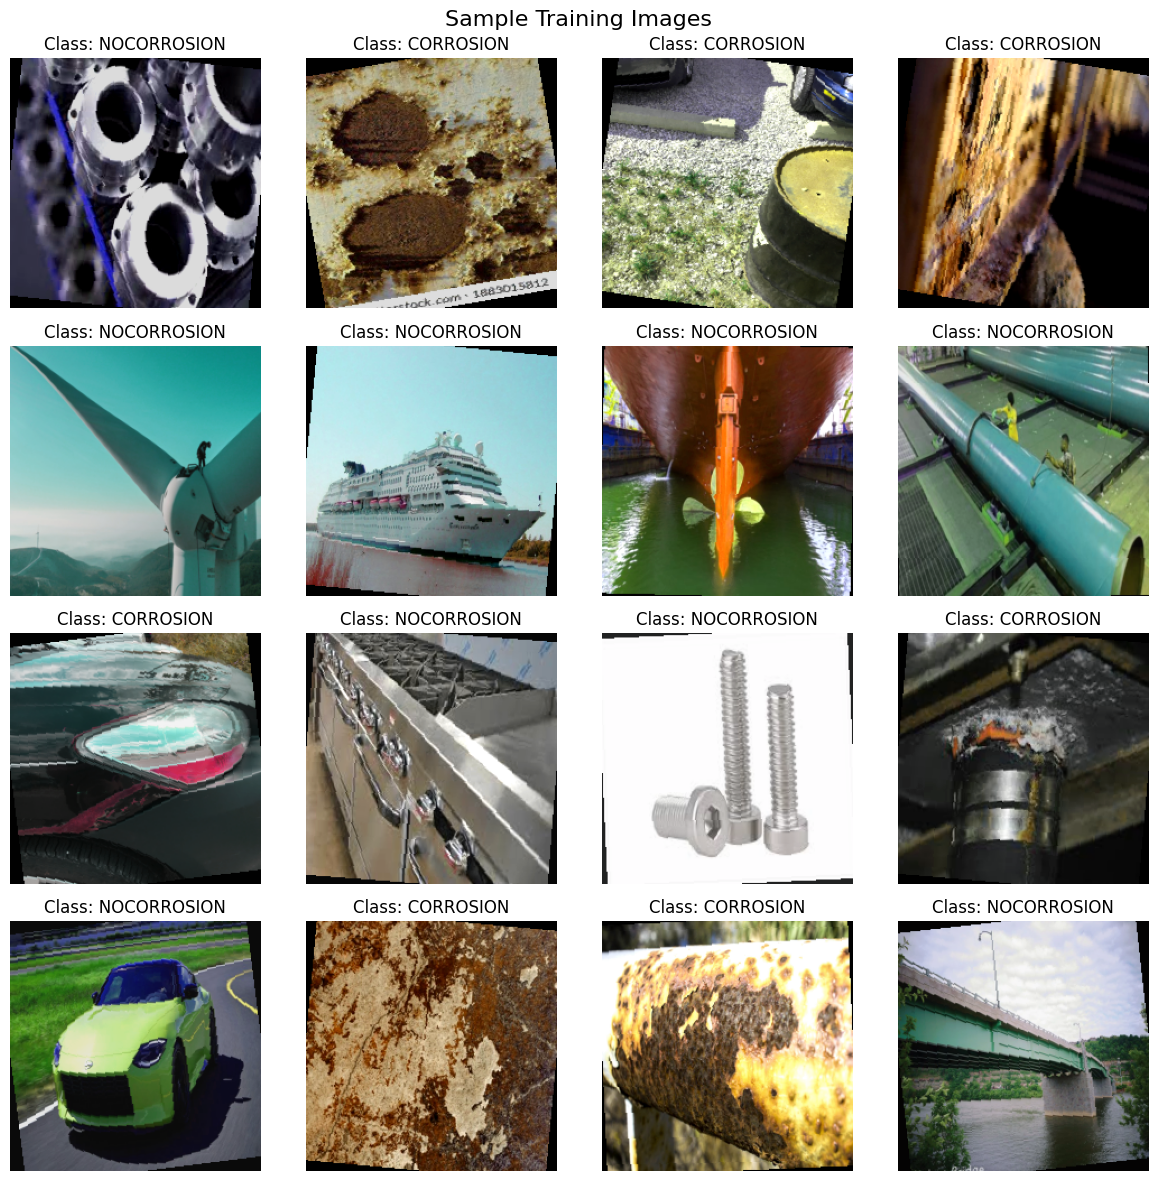


Class distribution in this batch:
  CORROSION: 7 images
  NOCORROSION: 9 images


In [31]:
# ============================================
# Visualize sample images (PIL method)
# ============================================

from torchvision.transforms.functional import to_pil_image

# Get a batch
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Batch shape: {images.shape}")
print(f"Number of images in batch: {len(images)}")

# Calculate grid size dynamically
n_images = min(16, len(images))  # Show up to 16 images
n_cols = 4
n_rows = (n_images + n_cols - 1) // n_cols  # Ceiling division

# Plot images
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
fig.suptitle('Sample Training Images', fontsize=16)

# Flatten axes for easy indexing
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

for i in range(n_images):
    # Denormalize
    img_tensor = images[i].cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)

    # Convert to PIL and display
    img_pil = to_pil_image(img_tensor)
    axes[i].imshow(img_pil)
    axes[i].set_title(f"Class: {train_dataset.classes[labels[i].item()]}")
    axes[i].axis('off')

# Turn off remaining axes
for i in range(n_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Show class distribution in this batch
print("\nClass distribution in this batch:")
unique, counts = np.unique(labels.numpy(), return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {train_dataset.classes[cls]}: {count} images")

In [32]:
# Debug: Check the entire dataset class distribution
print("=" * 50)
print("FULL DATASET CLASS DISTRIBUTION")
print("=" * 50)

for i, class_name in enumerate(train_dataset.classes):
    train_count = sum(1 for t in train_dataset.targets if t == i)
    val_count = sum(1 for t in val_dataset.targets if t == i)
    print(f"{class_name}:")
    print(f"  Train: {train_count} images")
    print(f"  Val: {val_count} images")
    print()

# Check a few individual samples
print("=" * 50)
print("SAMPLE IMAGE PATHS")
print("=" * 50)
for i in range(min(5, len(train_dataset))):
    path, label = train_dataset.samples[i]
    print(f"Sample {i}: {path}")
    print(f"  Label: {train_dataset.classes[label]}")
    print()

FULL DATASET CLASS DISTRIBUTION
CORROSION:
  Train: 693 images
  Val: 99 images

NOCORROSION:
  Train: 580 images
  Val: 83 images

SAMPLE IMAGE PATHS
Sample 0: /content/train/CORROSION/000008.jpg
  Label: CORROSION

Sample 1: /content/train/CORROSION/000009.jpg
  Label: CORROSION

Sample 2: /content/train/CORROSION/000018.jpg
  Label: CORROSION

Sample 3: /content/train/CORROSION/000019.jpg
  Label: CORROSION

Sample 4: /content/train/CORROSION/000020.jpg
  Label: CORROSION



In [33]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10, best_path="best_model.pt"):
    since = time.time()

    dataloaders = {"train": train_loader, "val": val_loader}
    dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}

    best_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    # For Hugging Face models, we need to access the logits
                    outputs = model(inputs)

                    # Handle different output formats
                    if hasattr(outputs, 'logits'):  # Hugging Face model
                        logits = outputs.logits
                    else:  # Regular PyTorch model
                        logits = outputs

                    _, preds = torch.max(logits, 1)
                    loss = criterion(logits, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train" and scheduler:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item() if hasattr(epoch_acc, 'item') else epoch_acc)

            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), best_path)

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history

In [34]:
# Disable symlink warning
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# Get number of classes
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset.classes}")

# Create label mappings
id2label = {i: label for i, label in enumerate(train_dataset.classes)}
label2id = {label: i for i, label in enumerate(train_dataset.classes)}

print(f"Label mapping: {id2label}")

# Load ViT model and processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

# Create ViT model
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id
)

# Move model to device
model = model.to(device)
print(f"Model loaded on: {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Number of classes: 2
Classes: ['CORROSION', 'NOCORROSION']
Label mapping: {0: 'CORROSION', 1: 'NOCORROSION'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded on: cuda
Number of parameters: 85,800,194


In [35]:
# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Loss function
criterion = nn.CrossEntropyLoss()

In [36]:
# Train the model
model, history = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=10,
    best_path="vit_rust_best.pt"
)

Epoch 1/10
----------
train Loss: 0.3567 Acc: 0.8445
val Loss: 0.1647 Acc: 0.9451

Epoch 2/10
----------
train Loss: 0.1138 Acc: 0.9670
val Loss: 0.1113 Acc: 0.9560

Epoch 3/10
----------
train Loss: 0.0494 Acc: 0.9890
val Loss: 0.0912 Acc: 0.9670

Epoch 4/10
----------
train Loss: 0.0277 Acc: 0.9945
val Loss: 0.0944 Acc: 0.9670

Epoch 5/10
----------
train Loss: 0.0181 Acc: 0.9976
val Loss: 0.0730 Acc: 0.9780

Epoch 6/10
----------
train Loss: 0.0082 Acc: 1.0000
val Loss: 0.0788 Acc: 0.9725

Epoch 7/10
----------
train Loss: 0.0132 Acc: 0.9969
val Loss: 0.0682 Acc: 0.9835

Epoch 8/10
----------
train Loss: 0.0081 Acc: 0.9976
val Loss: 0.0675 Acc: 0.9835

Epoch 9/10
----------
train Loss: 0.0087 Acc: 0.9984
val Loss: 0.0722 Acc: 0.9780

Epoch 10/10
----------
train Loss: 0.0049 Acc: 1.0000
val Loss: 0.0726 Acc: 0.9780

Training complete in 15m 31s
Best val Acc: 0.9835


**ATTENTION MAPS**


In [ ]:
# ============================================
# Attention Map Visualization
# ============================================

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def get_attention_maps(model, image_path, processor, device, layer=-1):
    """
    Extract attention maps from ViT model

    Args:
        model: ViT model
        image_path: path to image
        processor: ViT image processor
        device: torch device
        layer: which layer to visualize (-1 = last layer)

    Returns:
        attention_map: averaged attention map
        image: original image
        pred_class: predicted class
        confidence: prediction confidence
    """
    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)

    # Forward pass with attention output
    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

        # Get attention maps from specified layer
        attentions = outputs.attentions  # List of attention maps from each layer
        target_attention = attentions[layer]  # Shape: [batch, heads, seq_len, seq_len]

        # Average over attention heads
        attention = target_attention.mean(dim=1)[0]  # Shape: [seq_len, seq_len]

        # Extract CLS token attention to image patches
        cls_attention = attention[0, 1:]  # First token is CLS, rest are image patches

        # Reshape to grid
        grid_size = int(np.sqrt(len(cls_attention)))
        attention_map = cls_attention.cpu().numpy().reshape(grid_size, grid_size)

    return attention_map, image, pred_class.item(), confidence.item()

def visualize_attention(model, image_path, processor, device, class_names, save_path=None):
    """
    Visualize attention maps on image
    """
    # Get attention maps from different layers
    layers = [0, 3, 6, 9, 11]  # Early, middle, and late layers

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Original image
    img = Image.open(image_path).convert('RGB')
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Get prediction
    with torch.no_grad():
        inputs = processor(images=img, return_tensors="pt")
        pixel_values = inputs['pixel_values'].to(device)
        outputs = model(pixel_values)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

    axes[0].set_xlabel(f"Pred: {class_names[pred_class]} ({confidence:.2f})")

    # Visualize attention from different layers
    for i, layer_idx in enumerate(layers):
        attention_map, _, _, _ = get_attention_maps(
            model, image_path, processor, device, layer=layer_idx
        )

        # Resize attention map to image size
        attention_resized = cv2.resize(attention_map, (img.width, img.height))

        # Plot attention heatmap
        ax = axes[i+1]
        im = ax.imshow(img, alpha=0.7)
        im = ax.imshow(attention_resized, cmap='hot', alpha=0.3)
        ax.set_title(f'Layer {layer_idx} Attention')
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def analyze_attention_metrics(model, image_path, processor, device):
    """
    Analyze attention metrics to detect out-of-distribution images
    """
    attention_map, img, pred_class, confidence = get_attention_maps(
        model, image_path, processor, device, layer=-1
    )

    # Calculate attention metrics
    attention_std = np.std(attention_map)
    attention_entropy = -np.sum(attention_map * np.log(attention_map + 1e-10))
    attention_sparsity = np.sum(attention_map > 0.1) / attention_map.size

    print(f"Attention Metrics:")
    print(f"  Standard Deviation: {attention_std:.4f}")
    print(f"  Entropy: {attention_entropy:.4f}")
    print(f"  Sparsity (% pixels >0.1): {attention_sparsity:.2%}")

    # Interpretation
    print(f"\nInterpretation:")
    if attention_std < 0.05:
        print("  ⚠️  Attention is very diffuse - model may be confused")
    elif attention_std > 0.15:
        print("  ✅ Attention is focused - model is confident")
    else:
        print("  📊 Attention is moderately focused")

    return {
        'attention_map': attention_map,
        'std': attention_std,
        'entropy': attention_entropy,
        'sparsity': attention_sparsity,
        'pred_class': pred_class,
        'confidence': confidence
    }

In [ ]:
# ============================================
# Test attention on corrosion images
# ============================================

# Find a corrosion image
corrosion_indices = [i for i, (_, label) in enumerate(val_dataset.samples) if label == 0]
if corrosion_indices:
    corrosion_path, _ = val_dataset.samples[corrosion_indices[0]]
    print(f"Testing on corrosion image: {corrosion_path}")
    visualize_attention(model, corrosion_path, processor, device, val_dataset.classes)
    metrics = analyze_attention_metrics(model, corrosion_path, processor, device)

In [ ]:
# ============================================
# Test attention on clean metal images
# ============================================

# Find a clean metal image
clean_indices = [i for i, (_, label) in enumerate(val_dataset.samples) if label == 1]
if clean_indices:
    clean_path, _ = val_dataset.samples[clean_indices[0]]
    print(f"Testing on clean metal image: {clean_path}")
    visualize_attention(model, clean_path, processor, device, val_dataset.classes)
    metrics = analyze_attention_metrics(model, clean_path, processor, device)

Testing on clean metal image: rust_dataset\test\NOCORROSION\0aee9cae21.jpg


NameError: name 'visualize_attention' is not defined

In [ ]:
# ============================================
# Test attention on unknown images
# ============================================

# You'll need to provide a path to an unknown image
# This could be anything NOT rust-related (cat, car, landscape, etc.)

unknown_path = "path/to/your/unknown/image.jpg"  # CHANGE THIS PATH

if os.path.exists(unknown_path):
    print(f"Testing on unknown image: {unknown_path}")
    visualize_attention(model, unknown_path, processor, device, val_dataset.classes)
    metrics = analyze_attention_metrics(model, unknown_path, processor, device)

    # Check if model is confused
    if metrics['std'] < 0.05:
        print("\n✅ DETECTION: Model is confused by this unknown image!")
    else:
        print("\n⚠️  Model thinks it knows this image - may be misclassifying")
else:
    print(f"Please set unknown_path to a real image file")

Please set unknown_path to a real image file


In [ ]:
# ============================================
# Robust prediction using attention metrics
# ============================================

def robust_predict(model, image_path, processor, device, class_names,
                   confidence_threshold=0.8, attention_threshold=0.05):
    """
    Make prediction with attention-based out-of-distribution detection
    """
    # Get attention metrics
    metrics = analyze_attention_metrics(model, image_path, processor, device)

    # Check if model is confident
    if metrics['confidence'] < confidence_threshold:
        return {
            'class': 'REJECTED',
            'confidence': metrics['confidence'],
            'reason': 'Low confidence',
            'attention_std': metrics['std']
        }

    # Check if attention is too diffuse (model is confused)
    if metrics['std'] < attention_threshold:
        return {
            'class': 'REJECTED',
            'confidence': metrics['confidence'],
            'reason': 'Diffuse attention - image may be out-of-distribution',
            'attention_std': metrics['std']
        }

    # Prediction is accepted
    return {
        'class': class_names[metrics['pred_class']],
        'confidence': metrics['confidence'],
        'reason': 'Accepted',
        'attention_std': metrics['std']
    }

# Test on different types of images
test_images = [
    ("Corrosion", corrosion_path if corrosion_indices else None),
    ("Clean Metal", clean_path if clean_indices else None),
    ("Unknown", unknown_path if os.path.exists(unknown_path) else None)
]

for img_type, img_path in test_images:
    if img_path and os.path.exists(img_path):
        print(f"\n{'='*50}")
        print(f"Testing: {img_type}")
        print(f"{'='*50}")
        result = robust_predict(model, img_path, processor, device, val_dataset.classes)

        print(f"Result: {result['class']}")
        print(f"Confidence: {result['confidence']:.4f}")
        print(f"Reason: {result['reason']}")
        print(f"Attention STD: {result['attention_std']:.4f}")

In [ ]:
# ============================================
# Analyze attention on entire validation set
# ============================================

def analyze_validation_set(model, val_dataset, processor, device, n_samples=50):
    """
    Analyze attention metrics on validation set
    """
    attention_stds = []
    confidences = []
    predictions = []
    true_labels = []

    # Take random samples
    indices = np.random.choice(len(val_dataset), min(n_samples, len(val_dataset)), replace=False)

    for idx in indices:
        img_path, true_label = val_dataset.samples[idx]

        metrics = analyze_attention_metrics(model, img_path, processor, device)

        attention_stds.append(metrics['std'])
        confidences.append(metrics['confidence'])
        predictions.append(metrics['pred_class'])
        true_labels.append(true_label)

    # Convert to numpy
    attention_stds = np.array(attention_stds)
    confidences = np.array(confidences)
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Attention STD distribution
    axes[0, 0].hist(attention_stds, bins=20, edgecolor='black')
    axes[0, 0].set_xlabel('Attention Standard Deviation')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Attention STD Distribution')
    axes[0, 0].axvline(x=0.05, color='r', linestyle='--', label='Confusion threshold')
    axes[0, 0].legend()

    # Confidence distribution
    axes[0, 1].hist(confidences, bins=20, edgecolor='black')
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Confidence Distribution')

    # Attention STD vs Confidence
    colors = ['green' if p == t else 'red' for p, t in zip(predictions, true_labels)]
    axes[1, 0].scatter(confidences, attention_stds, c=colors, alpha=0.6)
    axes[1, 0].set_xlabel('Confidence')
    axes[1, 0].set_ylabel('Attention STD')
    axes[1, 0].set_title('Attention STD vs Confidence')
    axes[1, 0].axhline(y=0.05, color='r', linestyle='--', label='Confusion threshold')
    axes[1, 0].legend()

    # Accuracy by attention STD
    correct = (predictions == true_labels)
    bins = np.linspace(0, max(attention_stds), 10)
    correct_by_std = []
    std_bins = []

    for i in range(len(bins)-1):
        mask = (attention_stds >= bins[i]) & (attention_stds < bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(correct[mask])
            correct_by_std.append(acc)
            std_bins.append((bins[i] + bins[i+1])/2)

    axes[1, 1].plot(std_bins, correct_by_std, 'o-')
    axes[1, 1].set_xlabel('Attention STD')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('Accuracy vs Attention STD')
    axes[1, 1].axvline(x=0.05, color='r', linestyle='--')

    plt.tight_layout()
    plt.show()

    return attention_stds, confidences

# Run analysis
attention_stds, confidences = analyze_validation_set(model, val_dataset, processor, device)

**END ATTENTION MAPS**

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation function
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    return accuracy, all_preds, all_labels

# Evaluate
val_acc, val_preds, val_labels = evaluate_model(model, val_loader)